<a href="https://colab.research.google.com/github/22f2000792/MLP-prac/blob/main/BA_assign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np


In [2]:
train_df=pd.read_csv('/content/drive/MyDrive/Dataset/BA/train_LR.csv')
train_df.head(3)

,Tier,FICO,Term,Amount,Previous_Rate,Competition_rate,Rate,Cost_Funds,Partner Bin,Car_Type_N,Car_Type_R,Car_Type_U,Accept
0,2,729,66,22000.0,-10,5.75,6.29,1.1625,1,0,0,1,1
1,1,786,60,37000.0,-10,4.09,4.09,1.1400,2,1,0,0,0
2,1,742,60,25000.0,-10,3.99,3.99,1.1163,3,1,0,0,0


In [3]:
test_df=pd.read_csv('/content/drive/MyDrive/Dataset/BA/test_LR.csv')
test_df.head(3)

,Tier,FICO,Term,Amount,Previous_Rate,Competition_rate,Rate,Cost_Funds,Partner Bin,Car_Type_N,Car_Type_R,Car_Type_U,Accept
0,2,725,72,30500.0,5,6.09,4.99,1.120,2,0,1,0,0
1,1,739,60,25995.0,-10,4.79,4.79,1.959,2,0,0,1,0
2,2,715,48,30000.0,5,5.19,4.79,1.120,2,0,1,0,0


In [5]:
train_df.shape[0]

109244

In [6]:
test_df.shape[0]

36415

In [63]:
((train_df['Accept'] == 0).sum() / train_df.shape[0])*100

np.float64(78.0436454175973)

In [10]:
((train_df['Accept'] == 1).sum() / train_df.shape[0])*100


np.float64(21.956354582402696)

In [13]:
((test_df['Accept'] == 0).sum() / test_df.shape[0])*100


np.float64(77.85253329671839)

In [15]:
((test_df['Accept'] == 1).sum() / test_df.shape[0])*100

np.float64(22.147466703281616)

In [17]:
train_feature=train_df.drop('Accept',axis=1)
train_label=train_df['Accept'].copy()

In [18]:
train_feature.head(3)

,Tier,FICO,Term,Amount,Previous_Rate,Competition_rate,Rate,Cost_Funds,Partner Bin,Car_Type_N,Car_Type_R,Car_Type_U
0,2,729,66,22000.0,-10,5.75,6.29,1.1625,1,0,0,1
1,1,786,60,37000.0,-10,4.09,4.09,1.1400,2,1,0,0
2,1,742,60,25000.0,-10,3.99,3.99,1.1163,3,1,0,0


In [19]:
train_label.head(3)

,Accept
0,1
1,0
2,0


In [20]:
test_feature=test_df.drop('Accept',axis=1)
test_label=test_df['Accept'].copy()

In [21]:
test_feature.head(3)

,Tier,FICO,Term,Amount,Previous_Rate,Competition_rate,Rate,Cost_Funds,Partner Bin,Car_Type_N,Car_Type_R,Car_Type_U
0,2,725,72,30500.0,5,6.09,4.99,1.120,2,0,1,0
1,1,739,60,25995.0,-10,4.79,4.79,1.959,2,0,0,1
2,2,715,48,30000.0,5,5.19,4.79,1.120,2,0,1,0


In [22]:
test_label.head(3)

,Accept
0,0
1,0
2,0


In [42]:
from sklearn.linear_model import LogisticRegression
logr=LogisticRegression(random_state=17)
logr.fit(train_feature,train_label)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=17)

In [43]:
train_pred=logr.predict(train_feature)

In [48]:
from sklearn.metrics import accuracy_score
accuracy_score(train_label,train_pred)*100

81.48731280436454

In [45]:
logr.score(train_feature,train_label)

0.8148731280436454

In [46]:
from sklearn.metrics import classification_report


In [54]:
print(classification_report(train_label,train_pred, digits=4))

              precision    recall  f1-score   support

           0     0.8269    0.9648    0.8905     85258
           1     0.6927    0.2819    0.4007     23986

    accuracy                         0.8149    109244
   macro avg     0.7598    0.6233    0.6456    109244
weighted avg     0.7974    0.8149    0.7830    109244



In [55]:
pred_test=logr.predict(test_feature)

In [56]:
print(classification_report(test_label,pred_test, digits=4))

              precision    recall  f1-score   support

           0     0.8251    0.9647    0.8894     28350
           1     0.6935    0.2811    0.4000      8065

    accuracy                         0.8133     36415
   macro avg     0.7593    0.6229    0.6447     36415
weighted avg     0.7959    0.8133    0.7810     36415



In [58]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

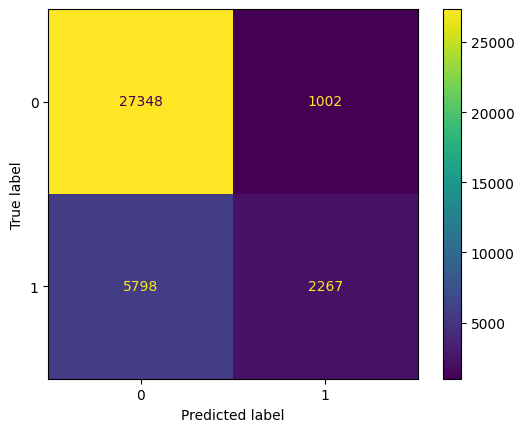

In [59]:
con_mat=confusion_matrix(test_label,pred_test)
ConfusionMatrixDisplay(con_mat).plot()
plt.show()
